# 1. Import Library

Mengimpor library yang dibutuhkan
- Untuk manipulasi data menggunakan DataFrame
- Untuk operasi numerik, seperti logaritma
- Untuk visualisasi data
- Untuk visualisasi data yang lebih menarik
- Untuk standarisasi data
- Untuk algoritma K-Means clustering
- Untuk evaluasi clustering
- Untuk reduksi dimensi dengan PCA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# 2. Membaca Data

In [ ]:
url = 'https://drive.google.com/uc?id=1y50wEz4t87XQ70-Khy6UCV98w984i1wQ'
data = pd.read_csv(url)
data

,NO,IDKOP,KOPERASI,ALAMAT,DESA,KELURAHAN,KECAMATAN,KABUPATEN,KESEHATAN,TAHUN IND KELEMBAGAAN,...,ASSET,VOLUME USAHA,TOTAL,SISA HASIL USAHA,IDPROPINSI,IDKABUPATEN,IDKECAMATAN,IDKELURAHAN,IDKOPERASI,KUK
0,1.0,3.501010e+12,Koperasi Simpan Pinjam Tani Karya Bhakti,Jalan Pacitan - Solo No 31,Donorojo,Donorojo,Donorojo,Kab. Pacitan,NaN,2021.0,...,1.262553e+08,1.840000e+08,1.262553e+08,12218500.0,35,1,10,20,1,1.0
1,2.0,3.501010e+12,KSP Harta Aji Mandiri,Jl. Raya Donorojo,Donorojo,Donorojo,Donorojo,Kab. Pacitan,NaN,2021.0,...,2.473491e+08,1.822854e+08,2.473491e+08,11935500.0,35,1,10,20,3,1.0
2,3.0,3.501010e+12,KOPERASI SIMPAN PINJAM DAN PEMBIAYAAN SYARIAH ...,"Jl. Solo - Pacitan, Druju",NaN,Donorojo,Donorojo,Kab. Pacitan,NaN,2023.0,...,9.224622e+10,9.908045e+09,9.224622e+10,562746715.0,35,1,10,20,4,3.0
3,7.0,3.501010e+12,KSPPS NURUL JANAH SEJAHTERA,NaN,Belah,Belah,Donorojo,Kab. Pacitan,NaN,2023.0,...,6.126606e+07,1.264330e+08,6.126606e+07,4971050.0,35,1,10,30,2,1.0
4,9.0,3.501010e+12,Koperasi Simpan Pinjam Padi Murni Sejahtera,RT 01 RW 08 Tumpak Watu,Widoro,Widoro,Donorojo,Kab. Pacitan,NaN,2023.0,...,2.688647e+08,4.148000e+08,2.688647e+08,30876500.0,35,1,10,40,20,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12692,21377.0,3.579030e+12,Koperasi Wahana Masyarakat Punten,Jl. Raya Punten 46 A Punten,Punten,Punten,Bumiaji,Kota Batu,Cukup Sehat,2023.0,...,3.634316e+08,4.167230e+07,3.634316e+08,7790272.0,35,79,30,81,16,1.0
12693,21378.0,3.579030e+12,Koperasi Wanita Sukses Melati Sejahtera,Jl. Raya Punten No. 19 A RT.2 RW. 2,Punten,Punten,Bumiaji,Kota Batu,NaN,2023.0,...,1.408705e+08,1.181330e+08,1.408705e+08,16166850.0,35,79,30,81,29,1.0
12694,21379.0,3.579030e+12,Koperasi Karyawan Sekarsari,Jl. Raya Punten No.1,Punten,Punten,Bumiaji,Kota Batu,NaN,2020.0,...,3.572735e+08,3.456829e+08,3.572735e+08,40985603.0,35,79,30,81,31,1.0
12695,21380.0,3.579030e+12,KOPERASI SIMPAN PINJAM PODHO JOYO MANDIRI,JALAN ANJASMORO NOMOR 24 GANG XI PAYAN,Punten,Punten,Bumiaji,Kota Batu,Cukup Sehat,2023.0,...,3.223749e+08,2.940985e+08,3.223749e+08,7624164.0,35,79,30,81,67,1.0


Kode ini membaca data dari URL yang diberikan dan menyimpannya dalam variabel data. data akan berupa objek DataFrame Pandas.



# 3. Eksplorasi Data

Menampilkan jumlah baris dan kolom data

In [ ]:
print("Dimensi dataset:", data.shape)

Dimensi dataset: (12697, 33)


Menampilkan informasi tentang tipe data dan missing values

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12697 entries, 0 to 12696
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NO                     12697 non-null  float64
 1   IDKOP                  12697 non-null  float64
 2   KOPERASI               12697 non-null  object 
 3   ALAMAT                 12456 non-null  object 
 4   DESA                   11613 non-null  object 
 5   KELURAHAN              12697 non-null  object 
 6   KECAMATAN              12697 non-null  object 
 7   KABUPATEN              12697 non-null  object 
 8   KESEHATAN              2556 non-null   object 
 9   TAHUN IND KELEMBAGAAN  12697 non-null  float64
 10  ANGGOTA PRIA           12697 non-null  object 
 11  ANGGOTA WANITA         12697 non-null  object 
 12  JUMLAH ANGGOTA         12697 non-null  object 
 13  MANAJER PRIA           12697 non-null  object 
 14  MANAJER WANITA         12697 non-null  object 
 15  JU

Menampilkan 5 baris pertama data

In [ ]:
print(data.head())

    NO         IDKOP                                           KOPERASI  \
0  1.0  3.501010e+12           Koperasi Simpan Pinjam Tani Karya Bhakti   
1  2.0  3.501010e+12                              KSP Harta Aji Mandiri   
2  3.0  3.501010e+12  KOPERASI SIMPAN PINJAM DAN PEMBIAYAAN SYARIAH ...   
3  7.0  3.501010e+12                        KSPPS NURUL JANAH SEJAHTERA   
4  9.0  3.501010e+12        Koperasi Simpan Pinjam Padi Murni Sejahtera   

                       ALAMAT      DESA KELURAHAN KECAMATAN     KABUPATEN  \
0  Jalan Pacitan - Solo No 31  Donorojo  Donorojo  Donorojo  Kab. Pacitan   
1           Jl. Raya Donorojo  Donorojo  Donorojo  Donorojo  Kab. Pacitan   
2   Jl. Solo - Pacitan, Druju       NaN  Donorojo  Donorojo  Kab. Pacitan   
3                         NaN     Belah     Belah  Donorojo  Kab. Pacitan   
4     RT 01 RW 08 Tumpak Watu    Widoro    Widoro  Donorojo  Kab. Pacitan   

  KESEHATAN  TAHUN IND KELEMBAGAAN  ...         ASSET  VOLUME USAHA  \
0       NaN    

Menampilkan jumlah missing values di setiap kolom

In [ ]:
print("Jumlah missing values tiap kolom:")
print(data.isnull().sum())

Jumlah missing values tiap kolom:
NO                           0
IDKOP                        0
KOPERASI                     0
ALAMAT                     241
DESA                      1084
KELURAHAN                    0
KECAMATAN                    0
KABUPATEN                    0
KESEHATAN                10141
TAHUN IND KELEMBAGAAN        0
ANGGOTA PRIA                 0
ANGGOTA WANITA               0
JUMLAH ANGGOTA               0
MANAJER PRIA                 0
MANAJER WANITA               0
JUMLAH MANAJER               0
KARYAWAN PRIA                0
KARYAWAN WANITA              0
JUMLAH KARYAWAN              0
RAT                          0
TAHUN IND USAHA              0
MODAL SENDIRI               11
MODAL LUAR                1404
ASSET                        0
VOLUME USAHA                 1
TOTAL                        0
SISA HASIL USAHA           568
IDPROPINSI                   0
IDKABUPATEN                  0
IDKECAMATAN                  0
IDKELURAHAN                  0
IDKOP

# 4. Membersihkan Data

Menghapus baris duplikat

In [ ]:
data_diskop = data.drop_duplicates()

Mengisi missing values numerik dengan median

In [ ]:
data_diskop.fillna(data_diskop.median(numeric_only=True), inplace=True)

Mendefinisikan parameter yang akan digunakan

In [ ]:
features = ['JUMLAH ANGGOTA', 'ASSET', 'VOLUME USAHA']

In [ ]:
data_diskop['JUMLAH ANGGOTA'] = data_diskop['JUMLAH ANGGOTA'].str.replace(',', '', regex=False)

Mengubah tipe data fitur menjadi numerik

In [ ]:
for col in features:
    data_diskop[col] = pd.to_numeric(data_diskop[col], errors='coerce')

Mengisi sisa missing values dengan median

In [ ]:
for col in features:
    if data_diskop[col].isnull().sum() > 0:
        data_diskop[col].fillna(data_diskop[col].median(), inplace=True)

<ipython-input-13-5781f1bb7a34>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_diskop[col].fillna(data_diskop[col].median(), inplace=True)


# 5. Transformasi Data

Membuat salinan data

In [ ]:
X = data_diskop[features].copy()

Menampilkan skewness setiap fitur

In [ ]:
print("Skewness tiap fitur sebelum transformasi:")
print(X.skew())

Skewness tiap fitur sebelum transformasi:
JUMLAH ANGGOTA     56.706709
ASSET             112.674978
VOLUME USAHA       65.678462
dtype: float64


Jika skewness > 1 (distribusi miring) Melakukan transformasi log untuk mengurangi skewness

In [ ]:
for col in X.columns:
    if X[col].skew() > 1:
        X[col] = np.log1p(X[col])

Membuat objek StandardScaler dan Melakukan standarisasi data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Menentukan Jumlah Cluster Optimal

List untuk menyimpan nilai inertia

In [ ]:
inertia = []

List untuk menyimpan nilai silhouette score

In [ ]:
silhouette_scores = []

Rentang jumlah cluster yang akan diuji (2 hingga 10)

In [ ]:
K = range(2, 11)

- Membuat objek KMeans dengan k cluster
- Melakukan clustering dan mendapatkan label cluster
- Menambahkan nilai inertia ke list
- Menambahkan nilai silhouette score ke list

In [ ]:
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

Membuat figure untuk plot

In [ ]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Elbow Method')

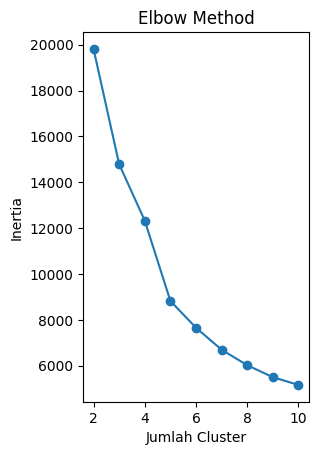

In [ ]:
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

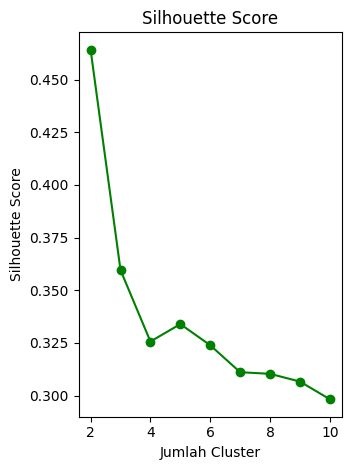

In [ ]:
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.tight_layout()
plt.show()

# 7. Melakukan Clustering

- Jumlah cluster optimal
- Membuat objek KMeans
- Melakukan clustering dan menambahkan label cluster ke DataFrame

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data_diskop['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = data_diskop.groupby('cluster')[features].mean()
print("Rangkuman rata-rata tiap cluster:")
print(cluster_summary)

Rangkuman rata-rata tiap cluster:
         JUMLAH ANGGOTA         ASSET  VOLUME USAHA
cluster                                            
0           1742.955403  2.888289e+11  1.491375e+10
1            113.189586  1.007734e+09  8.491482e+08
2             50.130931  9.628759e+07  7.857908e+07


In [ ]:
cluster_summary = data_diskop.groupby('cluster')[features].mean()
cluster_scores = cluster_summary.mean(axis=1)
cluster_performance = cluster_scores.sort_values(ascending=False)

In [ ]:
performance_mapping = {}
for i, cluster_id in enumerate(cluster_performance.index):
    if i == 0:
        performance_mapping[cluster_id] = 'Terbaik'
    elif i == len(cluster_performance) - 1:
        performance_mapping[cluster_id] = 'Terburuk'
    else:
        performance_mapping[cluster_id] = 'Menengah'

data_diskop['performance'] = data_diskop['cluster'].map(performance_mapping)

# 8. Visualisasi Cluster

- Membuat objek PCA untuk reduksi ke 2 dimensi
- Melakukan reduksi dimensi
- Menambahkan kolom 'pca1' (komponen utama 1) ke DataFrame
- Menambahkan kolom 'pca2' (komponen utama 2) ke DataFrame

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data_diskop['pca1'] = X_pca[:, 0]
data_diskop['pca2'] = X_pca[:, 1]

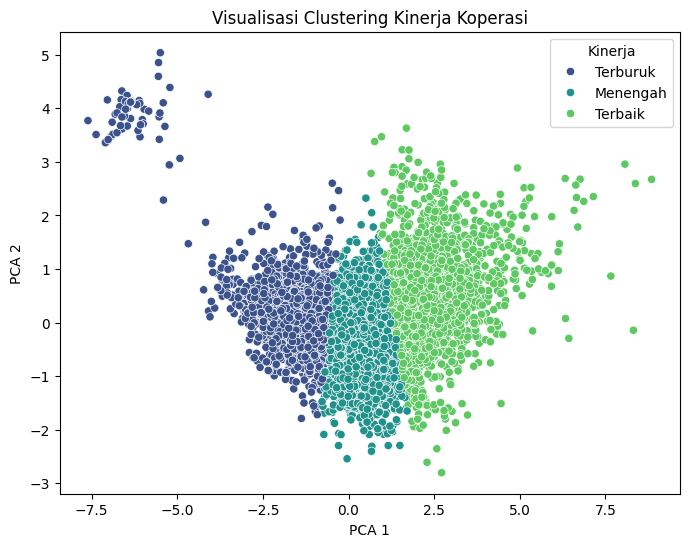

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='performance', data=data_diskop, palette='viridis')
plt.title("Visualisasi Clustering Kinerja Koperasi")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Kinerja')
plt.show()

# 9. Menampilkan Hasil

In [ ]:
hasil = data_diskop[['KOPERASI', 'performance']]
print("Contoh hasil pengelompokan koperasi:")
print(hasil.head(20))

Contoh hasil pengelompokan koperasi:
                                             KOPERASI performance
0            Koperasi Simpan Pinjam Tani Karya Bhakti    Terburuk
1                               KSP Harta Aji Mandiri    Menengah
2   KOPERASI SIMPAN PINJAM DAN PEMBIAYAAN SYARIAH ...     Terbaik
3                         KSPPS NURUL JANAH SEJAHTERA    Terburuk
4         Koperasi Simpan Pinjam Padi Murni Sejahtera    Menengah
5      Koperasi Simpan Pinjam Kemuning Lancar Mandiri    Menengah
6                             KSPPS BUKIT FAJAR INDAH    Terburuk
7           Koperasi Simpan Pinjam Himpulo Karya Kita    Menengah
8            Koperasi Simpan Pinjam Kelapa Sari Murni    Menengah
9           KOPERASI SIMPAN PINJAM PADI MURNI LESTARI    Terburuk
10        KOPERASI SIMPAN PINJAM TANDON ARTHA MANDIRI    Menengah
11           KOPERASI SIMPAN PINJAM SEKAR TAJI MAKMUR    Menengah
12                            KSP SEDYO UTOMO LESTARI    Menengah
13          Koperasi SImpan Pinjam Dewi

In [ ]:
terbaik = data_diskop[data_diskop['performance'] == 'Terbaik']
print("Koperasi dengan Kinerja Terbaik:")
print(terbaik[['KOPERASI', 'SISA HASIL USAHA']])
with open('koperasi_terbaik.txt', 'w') as f:
    for koperasi in terbaik['KOPERASI']:
        f.write("<item>"+koperasi+"</item>\n")

print("Data koperasi terbaik telah diekspor ke koperasi_terbaik.txt")

Koperasi dengan Kinerja Terbaik:
                                                KOPERASI  SISA HASIL USAHA
2      KOPERASI SIMPAN PINJAM DAN PEMBIAYAAN SYARIAH ...       562746715.0
15            KOPERASI KONSUMEN KPRI MARGA WIYATA MAKMUR        81714110.0
25                    Koperasi Unit Desa Adi Karya Utama         2250000.0
26             KOPERASI KONSUMEN KPRI ARTA DWIJA MANDIRI       351527948.0
37            KOPERASI KONSUMEN KPRI DWI TUNGGAL MANDIRI        15361000.0
...                                                  ...               ...
12652                Koperasi Pegawai Negeri Karya Praja       346625414.0
12671                       Koperasi Mitra Bhakti Makmur       402769250.0
12678                      Primer Koperasi Kartika Vyati       416848374.0
12681                Primkop Kartika Wikan Viyata Bhakti        95449507.0
12683                          Koperasi Karyawan Selecta        75602248.0

[2332 rows x 2 columns]
Data koperasi terbaik telah diekspor ke ko

In [ ]:
koperasi_terbaik_alamat = terbaik[['KOPERASI', 'ALAMAT']]
koperasi_terbaik_alamat['ALAMAT'] = koperasi_terbaik_alamat['ALAMAT'].fillna('-')

with open('koperasi_terbaik_alamat1.txt', 'w') as f:
    for alamat in koperasi_terbaik_alamat['ALAMAT']:
        f.write(f"<item>{alamat}</item>\n")

print("Alamat koperasi terbaik telah diekspor ke koperasi_terbaik_alamat.txt")

Alamat koperasi terbaik telah diekspor ke koperasi_terbaik_alamat.txt


<ipython-input-34-c18e1083febe>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  koperasi_terbaik_alamat['ALAMAT'] = koperasi_terbaik_alamat['ALAMAT'].fillna('-')


In [ ]:
terburuk = data_diskop[data_diskop['performance'] == 'Terburuk']
print("Koperasi dengan Kinerja Terburuk:")
print(terburuk[['KOPERASI', 'SISA HASIL USAHA']])

with open('koperasi_terburuk.txt', 'w') as f:
    for koperasi in terburuk['KOPERASI']:
        f.write("<item>"+koperasi+"</item>\n")

print("Data koperasi terbaik telah diekspor ke koperasi_terburuk.txt")

Koperasi dengan Kinerja Terburuk:
                                        KOPERASI  SISA HASIL USAHA
0       Koperasi Simpan Pinjam Tani Karya Bhakti        12218500.0
3                    KSPPS NURUL JANAH SEJAHTERA         4971050.0
6                        KSPPS BUKIT FAJAR INDAH         4976200.0
9      KOPERASI SIMPAN PINJAM PADI MURNI LESTARI        19604700.0
13     Koperasi SImpan Pinjam Dewi Ratih Lestari         3276400.0
...                                          ...               ...
12684   KOPERASI SIMPAN PINJAM PANCA BAKTI USAHA         2894700.0
12686   KOPERASI PRODUSEN LESTARI BERKAH BERSAMA         7100000.0
12692          Koperasi Wahana Masyarakat Punten         7790272.0
12693    Koperasi Wanita Sukses Melati Sejahtera        16166850.0
12696              Koperasi Wanita Sumberbrantas        17099239.0

[4911 rows x 2 columns]
Data koperasi terbaik telah diekspor ke koperasi_terburuk.txt


In [ ]:
koperasi_terburuk_alamat = terburuk[['KOPERASI', 'ALAMAT']]
koperasi_terburuk_alamat['ALAMAT'] = koperasi_terburuk_alamat['ALAMAT'].fillna('-')

with open('koperasi_terburuk_alamat.txt', 'w') as f:
    for alamat in koperasi_terburuk_alamat['ALAMAT']:
        f.write(f"<item>{alamat}</item>\n")

print("Alamat koperasi terburukk telah diekspor ke koperasi_terburuk_alamat.txt")

Alamat koperasi terburukk telah diekspor ke koperasi_terburuk_alamat.txt


<ipython-input-35-c9b7d53b8abe>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  koperasi_terburuk_alamat['ALAMAT'] = koperasi_terburuk_alamat['ALAMAT'].fillna('-')


In [ ]:
menengah = data_diskop[data_diskop['performance'] == 'Menengah']
print("Koperasi dengan Kinerja Menengah:")
print(menengah[['KOPERASI', 'SISA HASIL USAHA']])

with open('koperasi_menengah.txt', 'w') as f:
    for koperasi in menengah['KOPERASI']:
        f.write("<item>"+koperasi+"</item>\n")

print("Data koperasi terbaik telah diekspor ke koperasi_menengah.txt")

Koperasi dengan Kinerja Menengah:
                                             KOPERASI  SISA HASIL USAHA
1                               KSP Harta Aji Mandiri        11935500.0
4         Koperasi Simpan Pinjam Padi Murni Sejahtera        30876500.0
5      Koperasi Simpan Pinjam Kemuning Lancar Mandiri        10826000.0
7           Koperasi Simpan Pinjam Himpulo Karya Kita        28392100.0
8            Koperasi Simpan Pinjam Kelapa Sari Murni         8288860.0
...                                               ...               ...
12689                   Koperasi Margo Makmur Mandiri        65325076.0
12690                         Koperasi Wanita Mandiri        13390000.0
12691                KOPERASI MITRA BERSAMA SEJAHTERA        14953140.0
12694                     Koperasi Karyawan Sekarsari        40985603.0
12695       KOPERASI SIMPAN PINJAM PODHO JOYO MANDIRI         7624164.0

[5454 rows x 2 columns]
Data koperasi terbaik telah diekspor ke koperasi_menengah.txt


In [ ]:
koperasi_menengah_alamat = menengah[['KOPERASI', 'ALAMAT']]
koperasi_menengah_alamat['ALAMAT'] = koperasi_menengah_alamat['ALAMAT'].fillna('-')

with open('koperasi_menengah_alamat.txt', 'w') as f:
    for alamat in koperasi_menengah_alamat['ALAMAT']:
        f.write(f"<item>{alamat}</item>\n")

print("Alamat koperasi menengah telah diekspor ke koperasi_menengah_alamat.txt")

Alamat koperasi menengah telah diekspor ke koperasi_menengah_alamat.txt


<ipython-input-33-9682a7d5e4d4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  koperasi_menengah_alamat['ALAMAT'] = koperasi_menengah_alamat['ALAMAT'].fillna('-')


In [ ]:
data_diskop.to_excel('hasil_clustering_koperasi3.xlsx', index=False)
print("Data telah diekspor ke hasil_clustering_koperasi1.xlsx")

Data telah diekspor ke hasil_clustering_koperasi1.xlsx


#Model H5 TensorFlow

NameError: name 'model_new_summary' is not defined